# Real-Time Crisis Detection System
## Notebook 04 — Event Classification (Stage 2 — Real Dataset)
**Goal:** Fine-tune XLM-RoBERTa on crisis event types (7 classes).
Run inference on all posts. Save `classified_events.csv` and model weights.

**Stage 2 upgrade:** Auto-detects the large bulk dataset from NB01B (~10K+ rows).
Falls back to Stage 1 small dataset if NB01B hasn't been run yet.

In [1]:
import os, sys, warnings; warnings.filterwarnings('ignore')
IN_COLAB  = 'google.colab' in sys.modules
IN_KAGGLE = 'KAGGLE_URL_BASE' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/10Academy/crisis-detection-system'
elif IN_KAGGLE:
    PROJECT_DIR = '/kaggle/working/crisis-detection-system'
else:
    PROJECT_DIR = os.path.abspath('..')

DATA_PROCESSED = f'{PROJECT_DIR}/data/processed'
DATA_EXTERNAL  = f'{PROJECT_DIR}/data/external'
MODELS_DIR     = f'{PROJECT_DIR}/models/crisis_classifier'
UTILS_DIR      = f'{PROJECT_DIR}/utils'

for d in [MODELS_DIR, f'{MODELS_DIR}/model_weights', f'{MODELS_DIR}/tokenizer', DATA_EXTERNAL]:
    os.makedirs(d, exist_ok=True)

if UTILS_DIR not in sys.path:
    sys.path.insert(0, UTILS_DIR)

print(f' Ready. Project: {PROJECT_DIR}')

Mounted at /content/drive
✅ Ready. Project: /content/drive/MyDrive/10Academy/crisis-detection-system


In [2]:
!pip install -q transformers datasets accelerate scikit-learn seaborn matplotlib torch

In [3]:
# Load training data (Stage 2 auto-detect)
# Checks for bulk dataset from NB01B first, falls back to Stage 1 data.
import pandas as pd, numpy as np, json, pickle, re, os
import torch
from tqdm import tqdm; tqdm.pandas()

# 7-class taxonomy
CLASS_NAMES = ['flood', 'earthquake', 'fire', 'accident', 'violence', 'storm', 'other']
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {i: c for i, c in enumerate(CLASS_NAMES)}

# Auto-detect best available dataset
TRAINING_DATA_PATH = f'{DATA_EXTERNAL}/training_data.csv'   # Stage 2 bulk dataset
FALLBACK_PATH      = f'{DATA_PROCESSED}/posts_cleaned.csv'  # Stage 1 small dataset

if os.path.exists(TRAINING_DATA_PATH):
    df = pd.read_csv(TRAINING_DATA_PATH)
    if 'post_id' in df.columns:
        df = df.set_index('post_id')
# Rename raw_text → text_cleaned if needed
    if 'raw_text' in df.columns and 'text_cleaned' not in df.columns:
        df = df.rename(columns={'raw_text': 'text_cleaned'})
    print(f' Loaded STAGE 2 bulk training data: {len(df):,} posts')
    IS_LARGE_DATASET = True
else:
    df = pd.read_csv(FALLBACK_PATH, index_col='post_id')
    print(f'  Stage 2 data not found. Using Stage 1 data: {len(df)} posts')
    print('    Run 01b_bulk_dataset_loader.ipynb first for much better results!')
    IS_LARGE_DATASET = False

labeled   = df[df['label'].notna()].copy()
unlabeled = df[df['label'].isna()].copy()
print(f'Labeled: {len(labeled):,} | Unlabeled: {len(unlabeled):,}')

✅ Loaded STAGE 2 bulk training data: 33,035 posts
Labeled: 33,035 | Unlabeled: 0


In [4]:
# Map labels to 7-class taxonomy
LABEL_MAP = {
# English
    'flood': 'flood', 'floods': 'flood', 'flooding': 'flood',
    'hurricane': 'flood', 'cyclone': 'flood', 'typhoon': 'flood',
    'landslide': 'flood', 'mudslide': 'flood', 'tsunami': 'flood',
    'earthquake': 'earthquake', 'quake': 'earthquake',
    'eruption': 'earthquake', 'volcano': 'earthquake',
    'fire': 'fire', 'wildfire': 'fire', 'blaze': 'fire',
    'accident': 'accident', 'crash': 'accident', 'explosion': 'accident',
    'collapse': 'accident', 'derail': 'accident',
    'violence': 'violence', 'shooting': 'violence', 'attack': 'violence',
    'bombing': 'violence', 'terror': 'violence',
    'storm': 'storm', 'tornado': 'storm', 'hail': 'storm', 'blizzard': 'storm',
    'other': 'other', 'not_related': 'other', 'irrelevant': 'other',
# Indonesian
    'banjir': 'flood', 'gempa': 'earthquake', 'kebakaran': 'fire',
    'kecelakaan': 'accident', 'kekerasan': 'violence', 'badai': 'storm',
    'longsor': 'flood', 'erupsi': 'earthquake',
# CrisisNLP / HumAID labels
    'infrastructure_and_utility_damage': 'accident',
    'other_relevant_information': 'other',
    'rescue_volunteering_or_donation_effort': 'other',
    'affected_individuals': 'other',
    'displaced_people_and_evacuations': 'other',
    'injured_or_dead_people': 'other',
    'missing_or_found_people': 'other',
    'not_humanitarian': 'other',
    'vehicle_damage': 'accident',
    'sympathy_and_support': 'other',
    'requests_or_urgent_needs': 'other',
    'caution_and_advice': 'other',
    'donations_and_volunteering': 'other',
}

def map_label(lbl):
    if pd.isna(lbl): return None
    key = str(lbl).lower().strip().replace(' ', '_')
    if key in LABEL_MAP:
        return LABEL_MAP[key]
# Try substring match
    for klass in CLASS_NAMES:
        if klass in key:
            return klass
    return 'other'

labeled['label_mapped'] = labeled['label'].apply(map_label)
labeled = labeled[labeled['label_mapped'].isin(CLASS_NAMES)]
labeled['label_id'] = labeled['label_mapped'].map(CLASS_TO_ID)

print('Label distribution after mapping:')
print(labeled['label_mapped'].value_counts().to_string())

Label distribution after mapping:
label_mapped
flood         5000
violence      5000
fire          5000
other         5000
accident      4647
storm         4422
earthquake    3966


✅ Stratified split applied.

Train: 23,867 | Val: 4,212 | Test: 4,956

Class distribution in train set:
label_mapped
flood         3613
violence      3613
fire          3612
other         3612
accident      3358
storm         3194
earthquake    2865


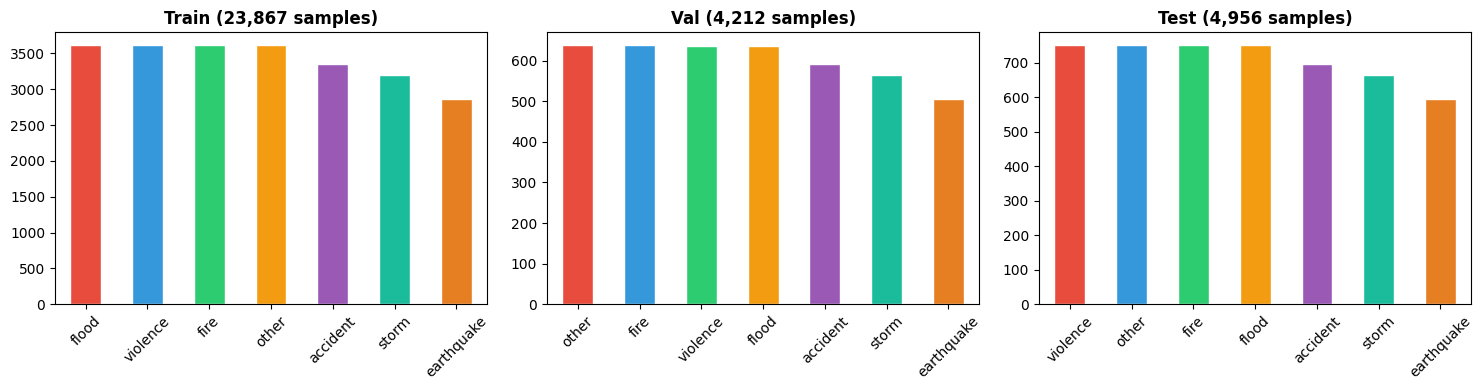


Class weights: {'flood': np.float32(0.944), 'earthquake': np.float32(1.19), 'fire': np.float32(0.944), 'accident': np.float32(1.015), 'violence': np.float32(0.944), 'storm': np.float32(1.067), 'other': np.float32(0.944)}


In [5]:
# Stratified train/val/test split
# For large datasets: use stratified random split (guarantees all classes present)
# For tiny datasets: fall back to simple split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Filter to only labeled rows with valid text
labeled = labeled.dropna(subset=['text_cleaned'])
labeled = labeled[labeled['text_cleaned'].str.len() >= 5]

MIN_SAMPLES_FOR_STRATIFY = len(CLASS_NAMES) * 4  # need at least 4 per class

if len(labeled) >= MIN_SAMPLES_FOR_STRATIFY and labeled['label_mapped'].nunique() >= 2:
    try:
# Stratified split: preserves class ratio across train/val/test
        df_trainval, df_test = train_test_split(
            labeled, test_size=0.15, random_state=42, stratify=labeled['label_mapped']
        )
        df_train, df_val = train_test_split(
            df_trainval, test_size=0.15, random_state=42, stratify=df_trainval['label_mapped']
        )
        print(' Stratified split applied.')
    except ValueError as e:
        print(f'  Stratified split failed ({e}). Falling back to random split.')
        df_trainval, df_test = train_test_split(labeled, test_size=0.15, random_state=42)
        df_train, df_val = train_test_split(df_trainval, test_size=0.15, random_state=42)
else:
# Dataset too small for stratified split
    n = len(labeled)
    df_train = labeled.iloc[:int(n * 0.70)]
    df_val   = labeled.iloc[int(n * 0.70):int(n * 0.85)]
    df_test  = labeled.iloc[int(n * 0.85):]
    print('  Dataset too small — using simple split. Run NB01B for better results.')

print(f'\nTrain: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print('\nClass distribution in train set:')
print(df_train['label_mapped'].value_counts().to_string())

# Plot splits
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
for ax, (split_df, title) in zip(axes, [
    (df_train, 'Train'), (df_val, 'Val'), (df_test, 'Test')
]):
    counts = split_df['label_mapped'].value_counts()
    counts.plot(kind='bar', ax=ax, color=colors[:len(counts)], edgecolor='white')
    ax.set_title(f'{title} ({len(split_df):,} samples)', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
os.makedirs(f'{PROJECT_DIR}/outputs/figures', exist_ok=True)
plt.savefig(f'{PROJECT_DIR}/outputs/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Compute class weights
from sklearn.utils.class_weight import compute_class_weight
unique_train_labels = np.unique(df_train['label_id'].values)
present_class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=unique_train_labels,
    y=df_train['label_id'].values
)
full_class_weights_arr = np.ones(len(CLASS_NAMES), dtype=np.float32)
for label, weight in zip(unique_train_labels, present_class_weights_arr):
    full_class_weights_arr[label] = weight
CLASS_WEIGHTS = torch.tensor(full_class_weights_arr, dtype=torch.float)
print(f'\nClass weights: {dict(zip(CLASS_NAMES, full_class_weights_arr.round(3)))}')

In [6]:
# Load tokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = 'xlm-roberta-base'
MAX_LEN    = 128

print(f'Loading tokenizer: {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(' Tokenizer loaded.')

Loading tokenizer: xlm-roberta-base ...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

✅ Tokenizer loaded.


In [7]:
# Build Dataset & DataLoaders
from torch.utils.data import Dataset, DataLoader

class CrisisDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_len=128):
        self.texts     = [str(t) for t in texts]
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        item = {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# Set batch size adaptively
BATCH_SIZE = 32 if IS_LARGE_DATASET else 8
NUM_EPOCHS = 5  if IS_LARGE_DATASET else 3
LR         = 2e-5

train_ds = CrisisDataset(df_train['text_cleaned'].tolist(), df_train['label_id'].tolist(), tokenizer, MAX_LEN)
val_ds   = CrisisDataset(df_val['text_cleaned'].tolist(),   df_val['label_id'].tolist(),   tokenizer, MAX_LEN)
test_ds  = CrisisDataset(df_test['text_cleaned'].tolist(),  df_test['label_id'].tolist(),  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f' DataLoaders ready.')
print(f'   Batch size: {BATCH_SIZE} | Epochs: {NUM_EPOCHS} | LR: {LR}')
print(f'   Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

✅ DataLoaders ready.
   Batch size: 32 | Epochs: 5 | LR: 2e-05
   Train batches: 746 | Val batches: 132


In [8]:
# Load XLM-RoBERTa model
from transformers import AutoModelForSequenceClassification
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

print(f'Loading model: {MODEL_NAME} ...')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(CLASS_NAMES),
    ignore_mismatched_sizes=True
)
model = model.to(DEVICE)
print(f' Model loaded. Parameters: {sum(p.numel() for p in model.parameters()):,}')

Device: cuda
Loading model: xlm-roberta-base ...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded. Parameters: 278,049,031


In [9]:
# Training loop
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import time

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps   = len(train_loader) * NUM_EPOCHS
warmup_steps  = int(total_steps * 0.1)
scheduler     = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# Weighted cross-entropy loss (handles class imbalance)
loss_fn = torch.nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(DEVICE))

def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids  = batch['input_ids'].to(device)
        attn_mask  = batch['attention_mask'].to(device)
        labels_b   = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        logits  = outputs.logits
        loss    = loss_fn(logits, labels_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        correct += (preds == labels_b).sum().item()
        total   += len(labels_b)

    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels_b  = batch['labels'].to(device)
            outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
            loss      = loss_fn(outputs.logits, labels_b)
            total_loss += loss.item()
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels_b).sum().item()
            total   += len(labels_b)
    return total_loss / len(loader), correct / total

print(f'Training XLM-RoBERTa for {NUM_EPOCHS} epochs...')
print(f'Total steps: {total_steps:,} | Warmup steps: {warmup_steps}')

best_val_acc   = 0.0
best_model_path = f'{MODELS_DIR}/model_weights/best_model.pt'
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, loss_fn, DEVICE)
    val_loss,   val_acc   = eval_epoch(model, val_loader, loss_fn, DEVICE)
    elapsed = time.time() - t0

    history.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
                    'val_loss': val_loss, 'val_acc': val_acc})

    print(f'Epoch {epoch}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} | '
          f'Time: {elapsed:.1f}s')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f'   New best model saved (val_acc={val_acc:.3f})')

print(f'\n Training complete! Best val accuracy: {best_val_acc:.3f}')

Training XLM-RoBERTa for 5 epochs...
Total steps: 3,730 | Warmup steps: 373
Epoch 1/5 | Train Loss: 0.5678 Acc: 0.822 | Val Loss: 0.1704 Acc: 0.948 | Time: 593.9s
  ✅ New best model saved (val_acc=0.948)
Epoch 2/5 | Train Loss: 0.1384 Acc: 0.961 | Val Loss: 0.1298 Acc: 0.964 | Time: 602.6s
  ✅ New best model saved (val_acc=0.964)
Epoch 3/5 | Train Loss: 0.0989 Acc: 0.973 | Val Loss: 0.1475 Acc: 0.964 | Time: 602.3s
Epoch 4/5 | Train Loss: 0.0710 Acc: 0.981 | Val Loss: 0.1415 Acc: 0.965 | Time: 601.0s
  ✅ New best model saved (val_acc=0.965)
Epoch 5/5 | Train Loss: 0.0517 Acc: 0.987 | Val Loss: 0.1482 Acc: 0.967 | Time: 601.5s
  ✅ New best model saved (val_acc=0.967)

✅ Training complete! Best val accuracy: 0.967


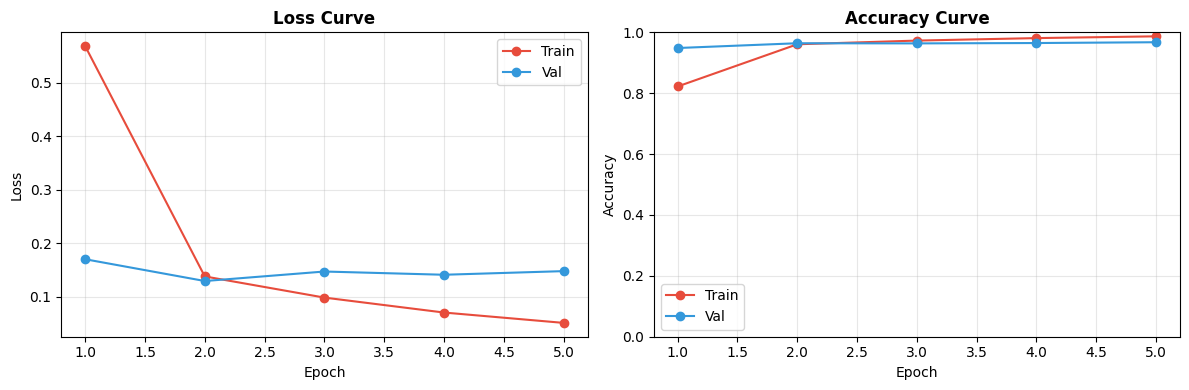

✅ Training curves saved.


In [10]:
# Plot training curves
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist_df['epoch'], hist_df['train_loss'], label='Train', marker='o', color='#e74c3c')
ax1.plot(hist_df['epoch'], hist_df['val_loss'],   label='Val',   marker='o', color='#3498db')
ax1.set_title('Loss Curve', fontweight='bold'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist_df['epoch'], hist_df['train_acc'], label='Train', marker='o', color='#e74c3c')
ax2.plot(hist_df['epoch'], hist_df['val_acc'],   label='Val',   marker='o', color='#3498db')
ax2.set_title('Accuracy Curve', fontweight='bold'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/outputs/figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Training curves saved.')

Evaluating: 100%|██████████| 155/155 [00:35<00:00,  4.41it/s]



=== TEST SET CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       flood       0.95      0.97      0.96       750
  earthquake       0.99      1.00      1.00       595
        fire       1.00      1.00      1.00       750
    accident       0.96      0.97      0.96       697
    violence       0.95      0.96      0.96       750
       storm       0.94      0.97      0.95       664
       other       0.94      0.86      0.90       750

    accuracy                           0.96      4956
   macro avg       0.96      0.96      0.96      4956
weighted avg       0.96      0.96      0.96      4956



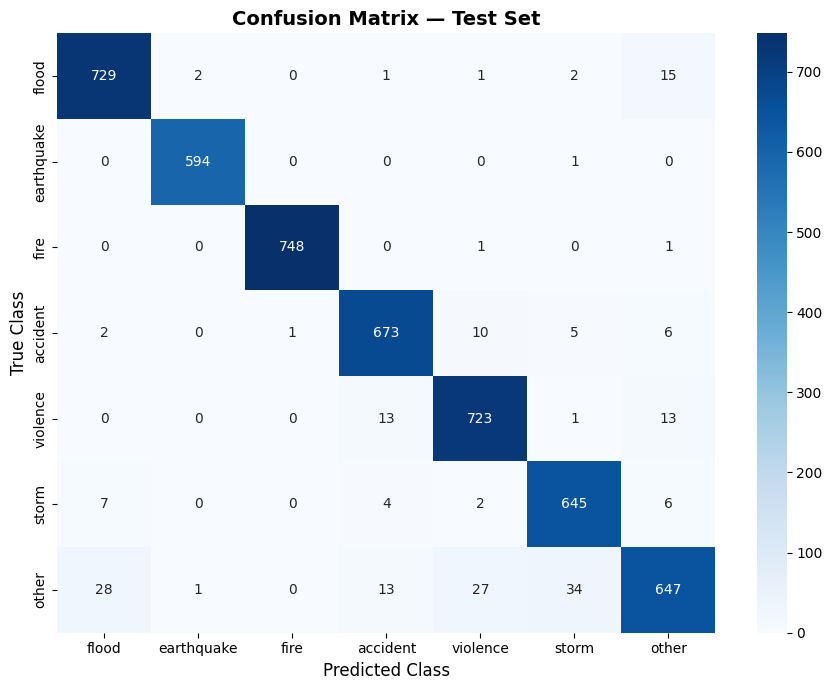

In [11]:
# Evaluate on test set
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best model
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluating'):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels_b  = batch['labels']
        outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
        preds     = outputs.logits.argmax(dim=-1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels_b.tolist())

print('\n=== TEST SET CLASSIFICATION REPORT ===')
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
ax.set_title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/outputs/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Save model and tokenizer
model.save_pretrained(f'{MODELS_DIR}/model_weights')
tokenizer.save_pretrained(f'{MODELS_DIR}/tokenizer')
print(f' Model saved: {MODELS_DIR}/model_weights')
print(f' Tokenizer saved: {MODELS_DIR}/tokenizer')

# Save label metadata
import json
with open(f'{MODELS_DIR}/label_config.json', 'w') as f:
    json.dump({'CLASS_NAMES': CLASS_NAMES, 'CLASS_TO_ID': CLASS_TO_ID, 'ID_TO_CLASS': {str(k): v for k, v in ID_TO_CLASS.items()}}, f, indent=2)
print(' Label config saved.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved: /content/drive/MyDrive/10Academy/crisis-detection-system/models/crisis_classifier/model_weights
✅ Tokenizer saved: /content/drive/MyDrive/10Academy/crisis-detection-system/models/crisis_classifier/tokenizer
✅ Label config saved.


In [13]:
# Run inference on ALL posts (including unlabeled)
CONFIDENCE_THRESHOLD = 0.70

# Build full dataset for inference (use posts_cleaned.csv from NB02 pipeline)
inference_path = f'{DATA_PROCESSED}/posts_cleaned.csv'
if os.path.exists(inference_path):
    df_infer = pd.read_csv(inference_path, index_col='post_id')
    print(f'Inference on pipeline posts: {len(df_infer)} rows')
else:
    df_infer = df.copy()
    print(f'Inference on training data: {len(df_infer)} rows')

infer_texts = df_infer['text_cleaned'].fillna('').astype(str).tolist()
infer_ds    = CrisisDataset(infer_texts, tokenizer=tokenizer, max_len=MAX_LEN)
infer_loader = DataLoader(infer_ds, batch_size=32, shuffle=False, num_workers=2)

model.eval()
all_probs, all_preds_infer = [], []

with torch.no_grad():
    for batch in tqdm(infer_loader, desc='Inference'):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
        probs     = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_preds_infer.extend(probs.argmax(axis=-1).tolist())

df_infer['predicted_class']     = [ID_TO_CLASS[p] for p in all_preds_infer]
df_infer['confidence_score']    = [max(p) for p in all_probs]
df_infer['class_probabilities'] = [json.dumps({CLASS_NAMES[i]: round(v, 4) for i, v in enumerate(p)}) for p in all_probs]

df_infer['classification_status'] = df_infer['confidence_score'].apply(
    lambda s: 'classified' if s >= CONFIDENCE_THRESHOLD else 'uncertain'
)

print(f'\n Inference complete on {len(df_infer)} posts.')
print(f'Threshold: {CONFIDENCE_THRESHOLD}')
print(df_infer['classification_status'].value_counts().to_string())
print('\nPredicted class distribution:')
print(df_infer['predicted_class'].value_counts().to_string())

Inference on pipeline posts: 75 rows


Inference: 100%|██████████| 3/3 [00:01<00:00,  2.99it/s]


✅ Inference complete on 75 posts.
Threshold: 0.7
classification_status
classified    68
uncertain      7

Predicted class distribution:
predicted_class
earthquake    28
other         24
flood         12
violence       4
accident       3
storm          3
fire           1


In [14]:
# Save classified events
out_path = f'{DATA_PROCESSED}/classified_events.csv'
df_infer.to_csv(out_path)
print(f' Saved classified_events.csv: {len(df_infer)} rows')
print(f'\n CLASSIFICATION COMPLETE ')
print(f'Best validation accuracy: {best_val_acc:.1%}')
print(f'Classified (confidence ≥ {CONFIDENCE_THRESHOLD}): {(df_infer["classification_status"]=="classified").sum()}')
print(f'Uncertain: {(df_infer["classification_status"]=="uncertain").sum()}')
print(f'\n Next: Run 05_credibility_and_clustering.ipynb')

✅ Saved classified_events.csv: 75 rows

═══ CLASSIFICATION COMPLETE ═══
Best validation accuracy: 96.7%
Classified (confidence ≥ 0.7): 68
Uncertain: 7

👉 Next: Run 05_credibility_and_clustering.ipynb
